### Transactions In Volume


In [10]:
# Import the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
Tran_Vol = pd.read_csv("../Datasets/Transaction_Vol.csv")
Tran_Vol.head()

,Region,Airtime top-up,Bill payment,Bulk disbursement,Cash-in,Cash-out,International remittance,Merchant payment,P2P transfer
0,Northern Africa,94668650,10874390,224408,21964363,10781904,6934,3187026,119917577
1,Eastern Africa,10372633412,6918249541,1533919684,6679798424,3939335112,90090348,5349117920,16879664292
2,Middle Africa,3202986015,94008178,27311053,1135556114,833943481,17116965,400875569,813836067
3,Northern Africa,94668650,10874390,224408,21964363,10781904,6934,3187026,119917577
4,Southern Africa,191754750,41130968,21366746,81292342,65235553,1867945,48905965,91307195


```
These transactions were done in 2024.
For our analysis, we will only consider these columns. (Airtime top-up, Bill payment, Cash-In and Cashh-Out)
```

In [12]:
Tran_Vol.info()
Tran_Vol.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Region                    6 non-null      object
 1   Airtime top-up            6 non-null      int64 
 2   Bill payment              6 non-null      int64 
 3   Bulk disbursement         6 non-null      int64 
 4   Cash-in                   6 non-null      int64 
 5   Cash-out                  6 non-null      int64 
 6   International remittance  6 non-null      int64 
 7   Merchant payment          6 non-null      int64 
 8   P2P transfer              6 non-null      int64 
dtypes: int64(8), object(1)
memory usage: 560.0+ bytes


Region                      0
Airtime top-up              0
Bill payment                0
Bulk disbursement           0
Cash-in                     0
Cash-out                    0
International remittance    0
Merchant payment            0
P2P transfer                0
dtype: int64

### Plotting histograms for these columns using their regions

In [13]:
Tran_Vol.columns = Tran_Vol.columns.str.lower().str.strip().str.replace(' ', '_')
print(Tran_Vol.columns.tolist())

['region', 'airtime_top-up', 'bill_payment', 'bulk_disbursement', 'cash-in', 'cash-out', 'international_remittance', 'merchant_payment', 'p2p_transfer']


In [14]:
target_columns = ['airtime_top-up', 'bill_payment', 'cash-in', 'cash-out']

In [15]:
import os

# Update this to the exact absolute path to your folder
Saved_Plots = "/home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots"

# This safety check ensures Python verifies the folder exists before saving
if not os.path.exists(Saved_Plots):
    print(f"Warning: The directory {Saved_Plots} was not found. Creating it now.")
    os.makedirs(Saved_Plots, exist_ok=True)

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_Vol_airtime_top-up.png


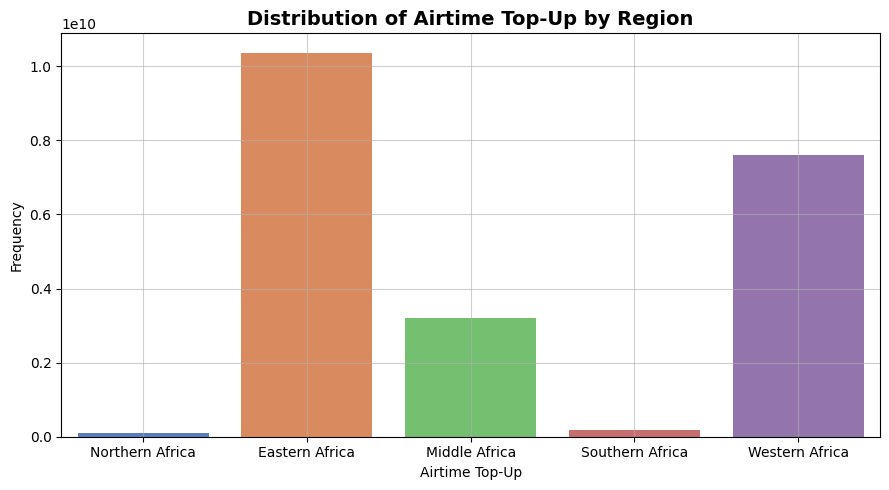

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_Vol_bill_payment.png


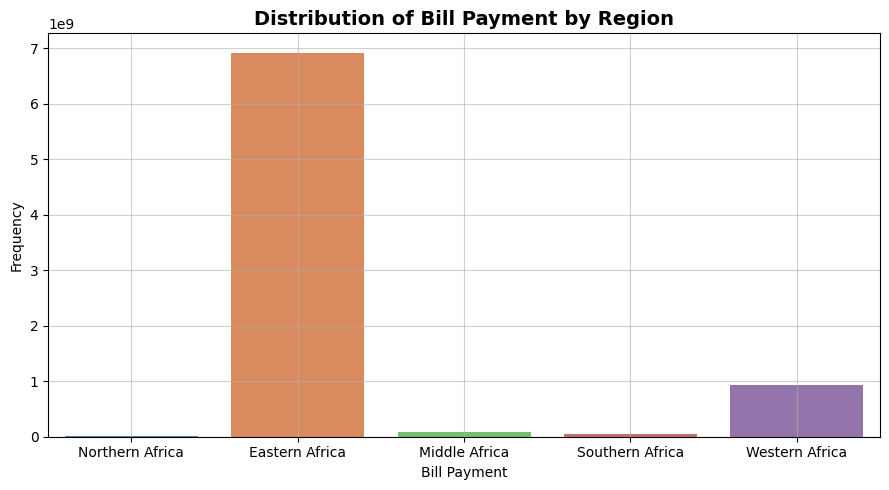

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_Vol_cash-in.png


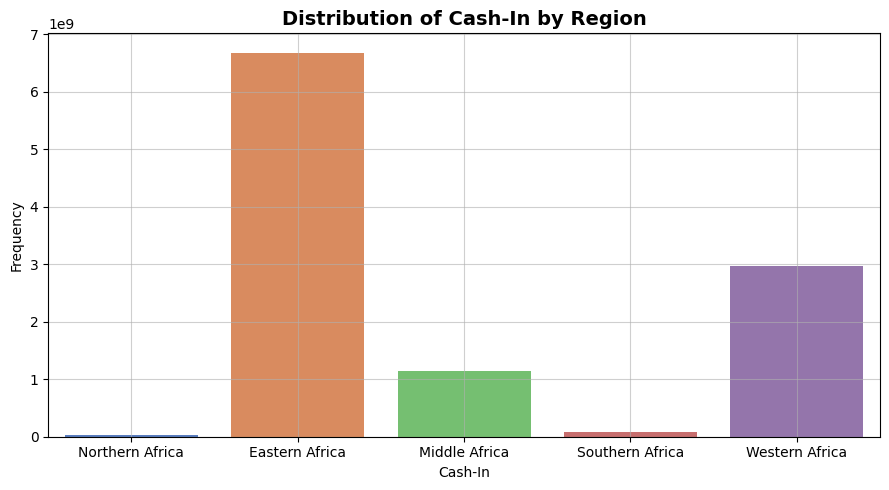

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_Vol_cash-out.png


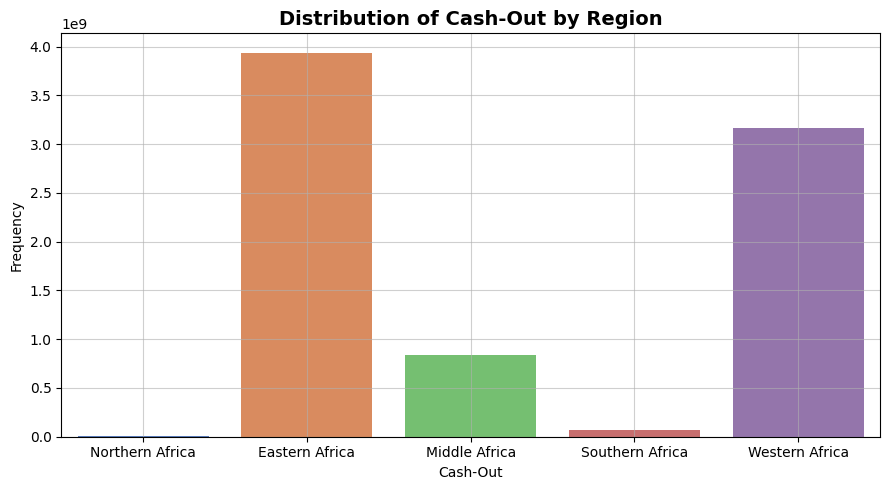

In [22]:
#Loop through each column and create a completely separate figure for each
for col in target_columns:
    if col in Tran_Vol.columns:
        # Create a brand new, individual figure window for this specific column
        plt.figure(figsize=(9, 5))
        
                # Using barplot instead of histplot to compare single totals cleanly
        sns.barplot(
            data=Tran_Vol,
            x='region',
            y=col,
            hue='region', # Keeps your beautiful regional color coding
            palette='muted',
            legend=False  # Legend is redundant here since region names are on the X-axis
        )
        
        # Clean up titles and labels for readability
        clean_title = col.replace('_', ' ').title()
        plt.title(f"Distribution of {clean_title} by Region", fontsize=14, fontweight='bold')
        plt.xlabel(clean_title)
        plt.ylabel("Frequency")
        plt.grid(True, linestyle="-", alpha=0.6)
        
        plt.tight_layout()
        
        # Save each graph as its own unique file
        file_name = f"Tran_Vol_{col}.png"
        save_path = os.path.join(Saved_Plots, file_name)
        plt.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
        
        # Display the current plot before moving on to the next one
        plt.show()
    else:
        print(f"Column '{col}' not found in dataframe.")

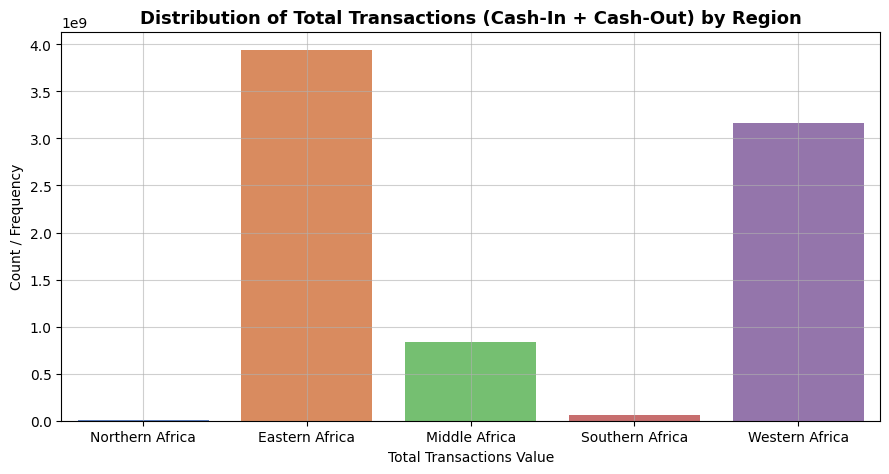

In [23]:
# 3. Create the 'total_transactions' column by adding cash-in and cash-out
# (Using .fillna(0) ensures that if one value is missing, it doesn't break the addition)
Tran_Vol['total_transactions'] = Tran_Vol['cash-in'].fillna(0) + Tran_Vol['cash-out'].fillna(0)

# 4. Create a separate figure for the Total Transactions graph
plt.figure(figsize=(9, 5))

        # Using barplot instead of histplot to compare single totals cleanly
sns.barplot(
    data=Tran_Vol,
    x='region',
    y=col,
    hue='region', # Keeps your beautiful regional color coding
    palette='muted',
    legend=False  # Legend is redundant here since region names are on the X-axis
)

# 5. Customize labels and appearance
plt.title("Distribution of Total Transactions (Cash-In + Cash-Out) by Region", fontsize=13, fontweight='bold')
plt.xlabel("Total Transactions Value")
plt.ylabel("Count / Frequency")
plt.grid(True, linestyle="-", alpha=0.6)

plt.tight_layout()

# Save the individual plot
plt.savefig("../Saved_Plots/Tran_Vol_total_transactions.png", dpi=300)
plt.show()